# **Análisis de Correlación e Integración de Datos para la Optimización del Ciclo de Ventas y Recaudo**

## **OBJETIVO DEL ANÁLISIS**

El objetivo principal del presente análisis es identificar la relación entre el valor de los productos vendidos **(monto_venta)** y el monto efectivamente recaudado **(total_pagado)**, con el fin de detectar posibles brechas financieras, evaluar la eficiencia del proceso de cobro y segmentar clientes según su nivel de riesgo.

Mediante técnicas de correlación, regresión lineal y clustering, se busca transformar los datos financieros en conocimiento estratégico que permita optimizar políticas de crédito, mejorar el flujo de caja y reducir riesgos de morosidad.


## **1. ESTRATEGIA DE CORRELACIÓN**
### **--- CARGA DE DATOS Y LIMPIEZA---**

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/DATOS.csv', sep=';', encoding='latin1')

df.columns = df.columns.str.strip().str.lower()

df = df.dropna(subset=['monto_venta','total_pagado','deuda_pendiente'])

df.head()

,ï»¿order_id,order_status,fecha_compra,monto_venta,valor_flete,total_pagado,deuda_pendiente,metodo_pago_principal
0,54282e97f61c23b78330c15b154c867d,shipped,2018-09-03 09:06:57.000,145.00,21.46,166.46,0.00,voucher
1,35a972d7f8436f405b56e36add1a7140,delivered,2018-08-29 15:00:37.000,84.99,8.76,93.75,0.00,credit_card
2,03ef5dedbe7492bdae72eec50764c43f,delivered,2018-08-29 14:52:00.000,24.90,8.33,33.23,0.00,credit_card
3,168626408cb32af0ffaf76711caae1dc,delivered,2018-08-29 14:18:28.000,45.90,15.39,61.29,0.00,voucher
4,0b223d92c27432930dfe407c6aea3041,delivered,2018-08-29 14:18:23.000,209.00,46.48,1021.92,-766.44,credit_card


### **--- CORRELACIÓN NUMÉRICA ---**

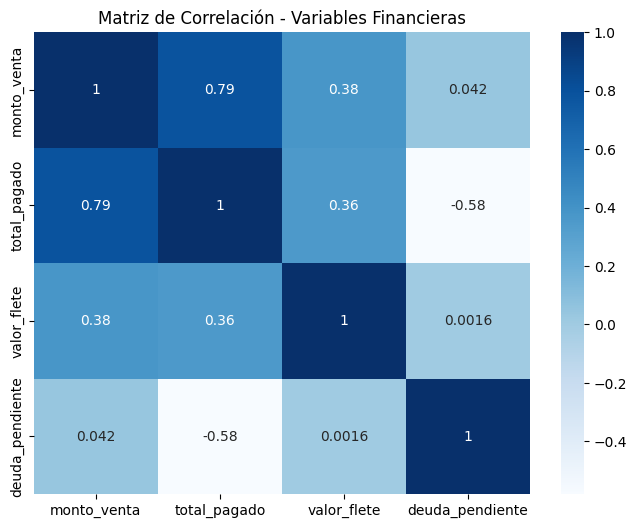

In [7]:
correlacion = df[['monto_venta','total_pagado','valor_flete','deuda_pendiente']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlacion, annot=True, cmap="Blues")
plt.title("Matriz de Correlación - Variables Financieras")
plt.show()

La matriz de correlación muestra los siguientes resultados:

*   La correlación entre monto_venta y total_pagado es **0.79**, lo que indica una relación positiva fuerte.
*   La correlación entre total_pagado y deuda_pendiente es **-0.58**, lo que sugiere que a mayor pago efectivo, menor deuda pendiente.

*  valor_flete presenta correlación moderada con monto_venta **(0.38)** y total_pagado **(0.36)**.
*   La relación entre monto_venta y deuda_pendiente es muy baja **(0.042)**, lo que indica que el riesgo no depende únicamente del valor vendido.

### **Interpretación:**
Se observa que existe una relación fuerte entre el monto de venta y el total pagado, lo que indica que en  general los clientes pagan de manera proporcional a lo que compran. Sin embargo, la deuda pendiente no depende directamente del monto vendido, sugiriendo que el problema no está en las ventas, sino enel comportamiento de pago de algunos clientes.

### **--- ANÁLISIS POR MÉTODO DE PAGO ---**

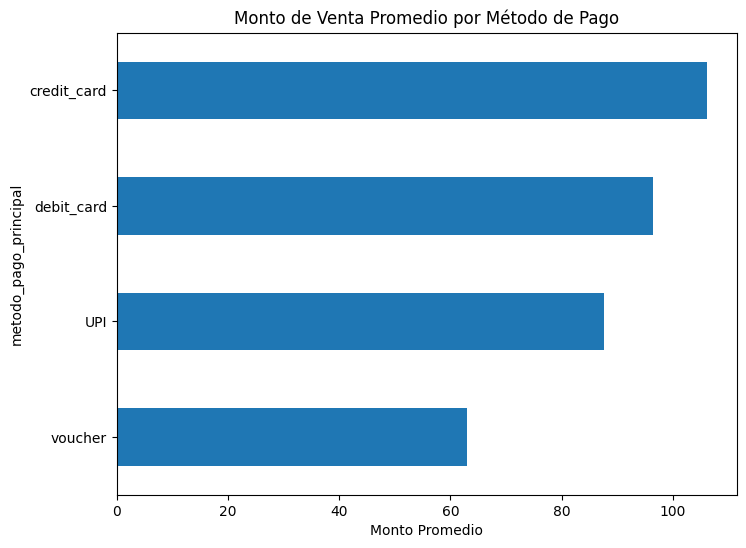

In [8]:
metodo = df.groupby('metodo_pago_principal')['monto_venta'].mean().sort_values()

metodo.plot(kind='barh', figsize=(8,6))
plt.title("Monto de Venta Promedio por Método de Pago")
plt.xlabel("Monto Promedio")
plt.show()

El análisis muestra que:

*   credit_card presenta el mayor monto promedio.
*   Le siguen debit_card, UPI, y finalmente voucher con el promedio más bajo.

### **Interpretación:**
Los clientes que utilizan tarjeta de crédito tienden a realizar compras de mayor valor. Esto sugiere que el crédito está asociado a mayor capacidad de gasto.

##**2. ESTRATEGIA DE REGRESIÓN**
### **--- REGRESIÓN VISUAL ---**

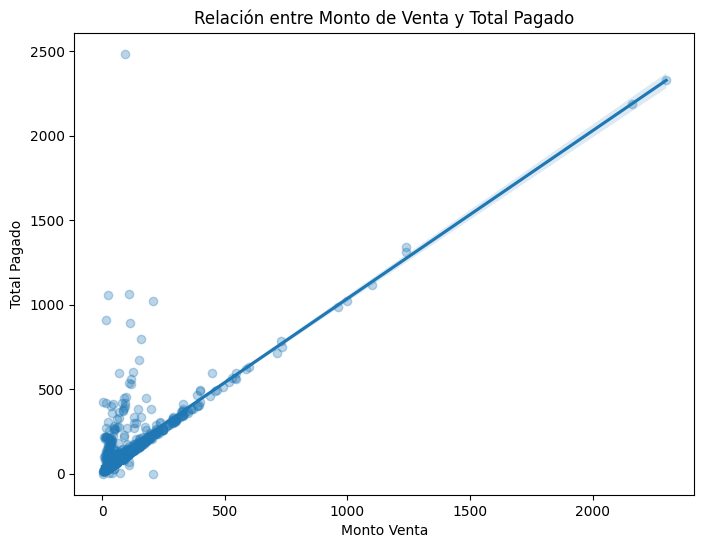

In [9]:
plt.figure(figsize=(8,6))
sns.regplot(
    x='monto_venta',
    y='total_pagado',
    data=df,
    scatter_kws={'alpha':0.3}
)

plt.title("Relación entre Monto de Venta y Total Pagado")
plt.xlabel("Monto Venta")
plt.ylabel("Total Pagado")
plt.show()

El gráfico de dispersión muestra una clara alineación de los puntos alrededor de la línea de regresión, aunque existen algunos valores atípicos alejados de la línea ideal.

### **--- MODELO DE REGRESIÓN LINEAL ---**

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[['monto_venta']]
y = df['total_pagado']

modelo = LinearRegression()
modelo.fit(X,y)

print("Pendiente:", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)
print("R2:", r2_score(y, modelo.predict(X)))

Pendiente: 0.9938358273955341
Intercepto: 42.97257614639071
R2: 0.6200774073784343


### **Interpretación:**

*   La pendiente cercana a 1 indica que el pago crece casi proporcionalmente al monto de venta.
*   El intercepto positivo (~43) sugiere que existen costos adicionales promedio (probablemente flete).
*   El R² de 0.62 indica que el 62% de la variabilidad del pago se explica por el monto de venta.

Como conclusión el sistema de cobro es coherente en general, pero existe variabilidad que podría explicarse por logística o deuda pendiente.

### **--- DETECCIÓN DE BRECHAS ---**

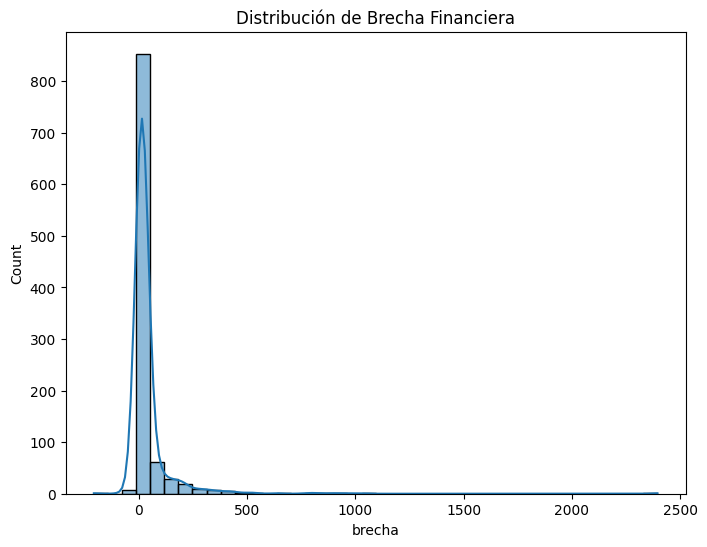

In [11]:
df['brecha'] = df['total_pagado'] - df['monto_venta']

plt.figure(figsize=(8,6))
sns.histplot(df['brecha'], bins=40, kde=True)
plt.title("Distribución de Brecha Financiera")
plt.show()

###**Interpretación:**

*   Brechas cercanas a cero indican pagos correctos.
*   Brechas positivas reflejan impacto del flete.
*   Brechas negativas pueden indicar pagos incompletos o inconsistencias.

Esto sugiere que aunque el sistema funciona adecuadamente en promedio, existen casos puntuales que requieren control y monitoreo.

### **--- MÉTODO DEL CODO ---**

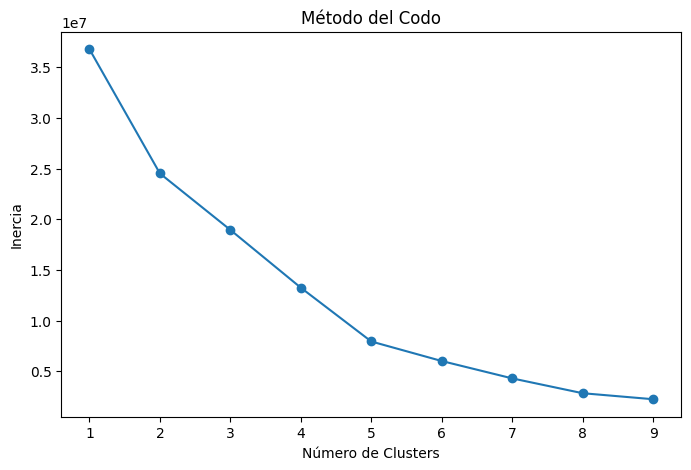

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = df[['monto_venta','deuda_pendiente']]

inercia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,10), inercia, marker='o')
plt.title("Método del Codo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.show()

### **--- SEGMENTACIÓN DE CLIENTES ---**

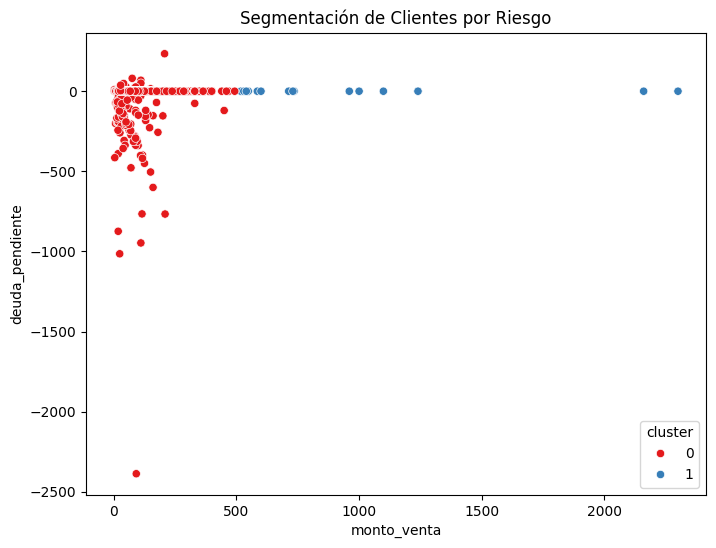

In [15]:
from sklearn.cluster import KMeans

segmento = df[['monto_venta','deuda_pendiente']]

kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='monto_venta',
    y='deuda_pendiente',
    hue='cluster',
    data=df,
    palette='Set1'
)
plt.title("Segmentación de Clientes por Riesgo")
plt.show()

###**Cluster 0 – Riesgo Financiero**

*   Alta dispersión en deuda pendiente.
*   Presencia de valores negativos significativos.
*   Mayor variabilidad respecto a la línea de regresión.

Este grupo requiere monitoreo activo.
###**Cluster 1 – Bajo Riesgo**

*   Monto de venta medio-alto.
*   Deuda pendiente cercana a cero.
*   Comportamiento financiero estable.

Representa clientes saludables para el flujo de caja.